## Figure 1a

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from scipy.interpolate import griddata
# from mpl_toolkits.basemap import Basemap
from matplotlib.colors import LogNorm

from scipy.stats import pearsonr


      Lon    Lat    Year  Month   Day       Mag  Depth  Hour  Minute  Second  \
0  -27.78  38.82  1980.0    1.0   1.0  6.899138   10.0  16.0    42.0    40.0   
1   58.70 -31.15  1980.0    1.0   2.0  5.585711   10.0  11.0    20.0     4.9   
2   67.18   0.04  1980.0    1.0   3.0  5.973799   10.0  18.0    11.0    51.4   
3   57.19  33.49  1980.0    1.0  12.0  6.002536   33.0  15.0    31.0    42.0   
4  143.59  41.68  1980.0    1.0  12.0  6.114561   33.0  15.0    57.0     1.9   

   Strike1  Dip1  Rake1  Strike2  Dip2  Rake2  Class   Mc          HF  
0    241.0  67.0 -171.0    148.0  82.0  -23.0    4.0  5.5  156.497020  
1    109.0  25.0  -44.0    240.0  73.0 -108.0    2.0  5.5  181.793770  
2    306.0  41.0 -105.0    146.0  51.0  -77.0    2.0  5.5  260.608760  
3    356.0  23.0  145.0    118.0  77.0   71.0    1.0  5.5   63.862415  
4    212.0   9.0  103.0     19.0  81.0   88.0    4.0  5.5   67.602433  


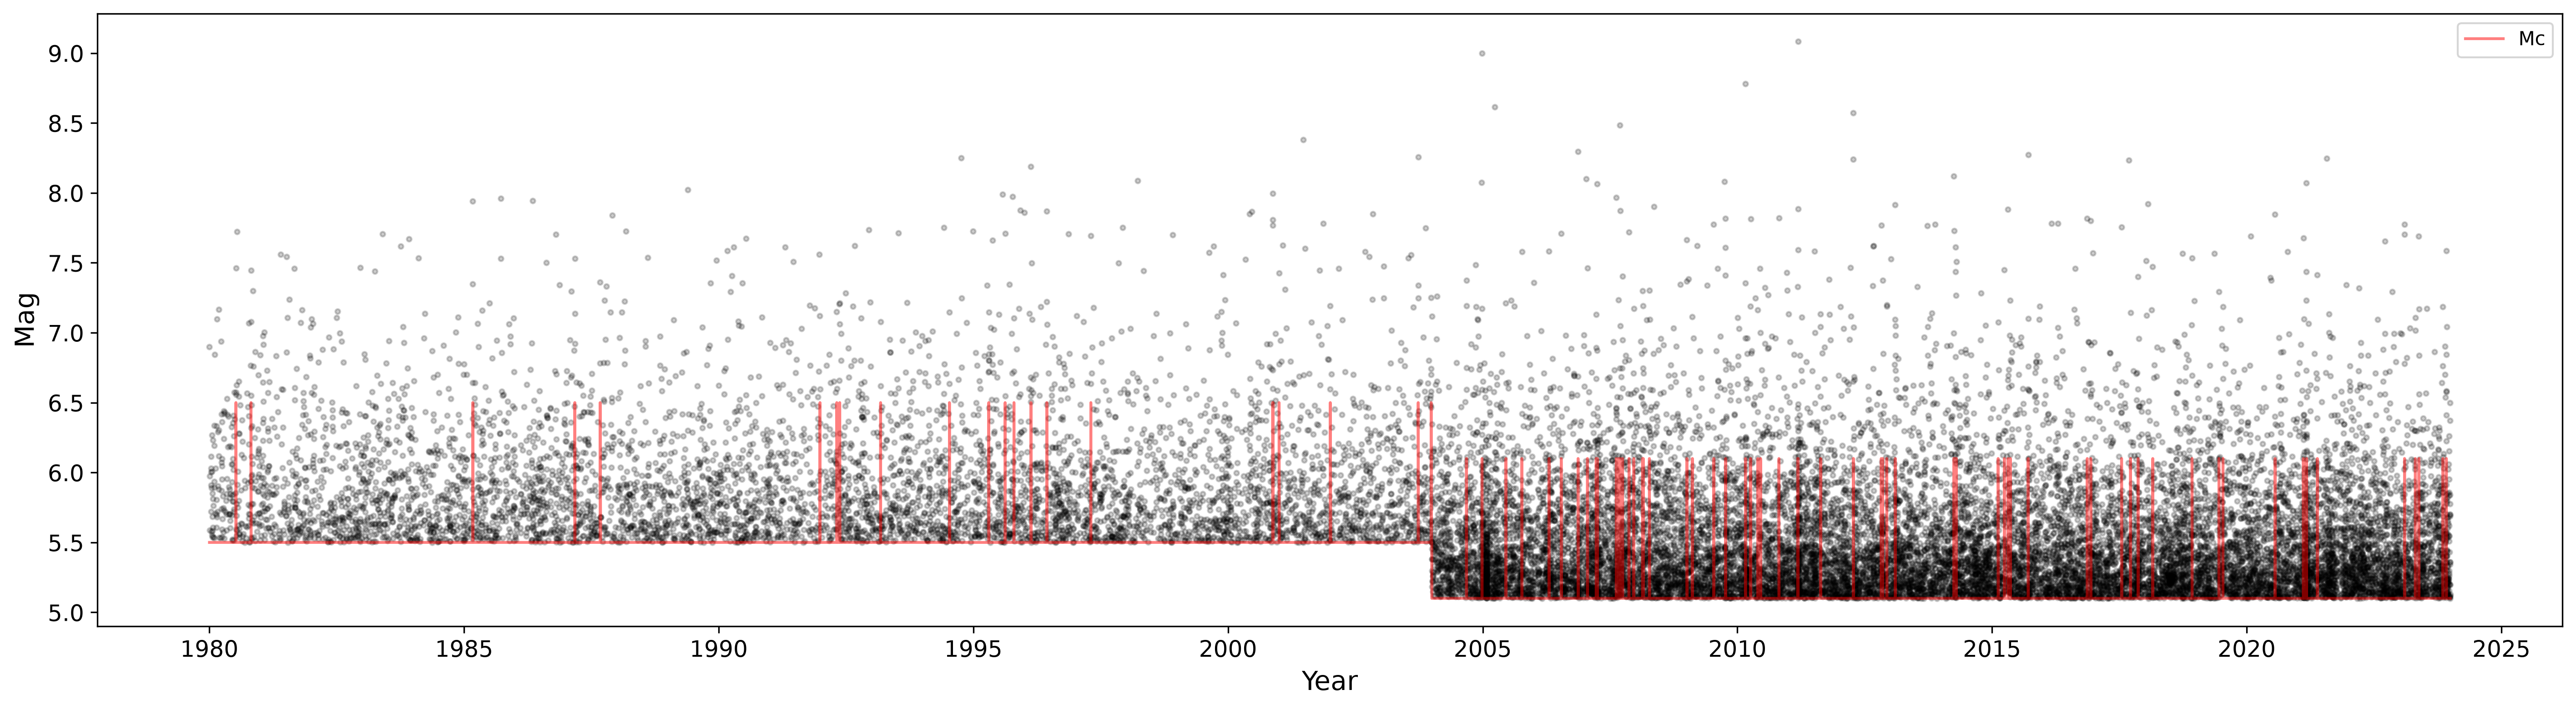

In [16]:
df = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])
print(df.head())

df['DateTime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']], errors='coerce')

plt.figure(figsize=(37 / 25.4 * 8*2, 37 / 25.4 * 4), dpi=300)
plt.plot(df.DateTime, df.Mag, '.', c='k', ms=5, alpha=0.2)
plt.plot(df.DateTime, df.Mc, '-', color='red', alpha = 0.5, linewidth=1.5, label='Mc')  # Linea rossa per la colonna Mc


plt.xlabel('Year', fontsize=14)  
plt.ylabel('Mag', fontsize=14)   
plt.xticks(fontsize=12)          
plt.yticks(fontsize=12)          


plt.legend(fontsize=26)
plt.legend()

plt.show()


## Figure 1b

NameError: name 'Basemap' is not defined

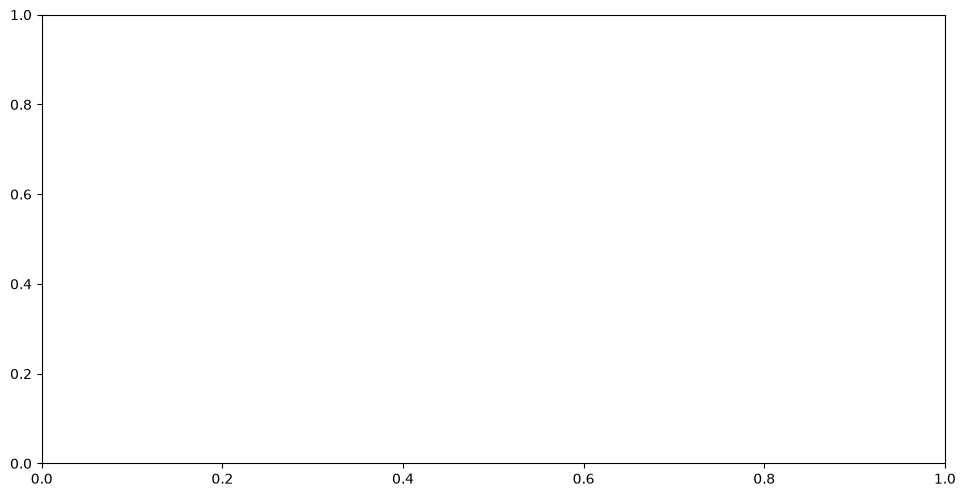

In [ ]:
Dati = pd.read_csv('HF.csv', delim_whitespace=False)
Dati2 = pd.read_csv('Catalog_Complete_1980_2023_Depth50_withHF.txt', delim_whitespace=True)
Dati2 = Dati2[Dati2.Mag >= Dati2.Mc]

fig, ax = plt.subplots(figsize=(37 / 25.4 * 8, 37 / 25.4 * 4))
m = Basemap(projection='cyl', llcrnrlat=-90, urcrnrlat=90, llcrnrlon=-180, urcrnrlon=180, resolution='c')

# Grid for interp
grid_x, grid_y = np.meshgrid(
    np.linspace(Dati['Longitude'].min(), Dati['Longitude'].max(), 100),
    np.linspace(Dati['Latitude'].min(), Dati['Latitude'].max(), 100)
)

# HF interp
grid_HF = griddata(
    (Dati['Longitude'].values, Dati['Latitude'].values),
    Dati['Mean_HF'].values,
    (grid_x, grid_y),
    method='linear'
)

x_grid, y_grid = m(grid_x, grid_y)
cmap = m.pcolormesh(x_grid, y_grid, grid_HF, cmap='viridis', norm=LogNorm(), shading='auto')

m.drawcoastlines(color='k', linewidth=0.5)  

# Earthquakes
x2, y2 = m(Dati2['Lon'].values, Dati2['Lat'].values)
size_scale = 1  # dots dimension related to magnitude
sizes = Dati2['Mag'] * size_scale
m.scatter(x2, y2, color='black', s=sizes, alpha=0.5, label='CMT (from 1980 to 2023)')

cbar = fig.colorbar(cmap, ax=ax, fraction=0.023, pad=0.04, orientation='vertical')
cbar.set_label('Heat Flow (mW m$^{-2}$)')

plt.legend(loc='lower left')

plt.show()


## Figure 2

In [21]:
Dati = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])

# uncomment for figure 2c,d,e
#Dati = Dati[(Dati['Rake1'] >= -135) & (Dati['Rake1'] <= -45)] # normal
#Dati = Dati[(Dati['Rake1'] >= 45) & (Dati['Rake1'] <= 135)] # reverse
# Dati_ssd = Dati[(Dati['Rake1'] > -45) & (Dati['Rake1'] < 45)] ##ss
# Dati_sss = Dati[(Dati['Rake1'] > 135) & (Dati['Rake1'] < -135)]# ss
# Dati = pd.concat([Dati_ssd, Dati_sss]).reset_index(drop=True) #ss

# uncomment for fiture sb
#Dati = Dati[(Dati['Class'] == 0) | (Dati['Class'] == 1) | (Dati['Class'] == 4)]

ColonnaInfo = 18  # HF

# number of intervals
Intervalli = 30

NumEventi = []
Bvalue = []
Beta = []
Sigma = []
HF_medio = []
HF_std = []

for i in range(1, Intervalli + 1):
    PercentileUP = i * 100 / Intervalli
    PercentileLOW = (i - 1) * 100 / Intervalli

    HF_P_UP = np.percentile(Dati.iloc[:, ColonnaInfo], PercentileUP)
    HF_P_LOW = np.percentile(Dati.iloc[:, ColonnaInfo], PercentileLOW)

    DatiOk = Dati[(Dati.iloc[:, ColonnaInfo] >= HF_P_LOW) & (Dati.iloc[:, ColonnaInfo] < HF_P_UP)]
    
    
    num_eventi = len(DatiOk)
    NumEventi.append(num_eventi)
# Taroni implementarion for b value
    if num_eventi > 1:
        mean_magnitude_diff = np.mean(DatiOk.iloc[:, 5] - DatiOk.iloc[:, 17])
        b_value = (num_eventi - 1) / num_eventi * 1 / (np.log(10) * mean_magnitude_diff)
        Bvalue.append(b_value)
        sigma = b_value / np.sqrt(num_eventi)
        Sigma.append(sigma)
        hf_medio = np.mean(DatiOk.iloc[:, ColonnaInfo])
        hf_std = np.std(DatiOk.iloc[:, ColonnaInfo])
        HF_medio.append(hf_medio)
        HF_std.append(hf_std)
    else:
        Bvalue.append(np.nan)
        Sigma.append(np.nan)
        HF_medio.append(np.nan)
        HF_std.append(np.nan)

Mean_N = np.mean(NumEventi)
print(f"Mean number of events: {Mean_N}")

HF_medio_valid = np.array(HF_medio)[~np.isnan(Bvalue)]
Bvalue_valid = np.array(Bvalue)[~np.isnan(Bvalue)]
Rho, Pvalue = pearsonr(HF_medio_valid, Bvalue_valid)
print(f"Correlation coeff: {Rho}")
print(f"P-value: {Pvalue}")


Mean number of events: 749.1333333333333
Correlation coeff: 0.845807002486903
P-value: 3.991481207082159e-09


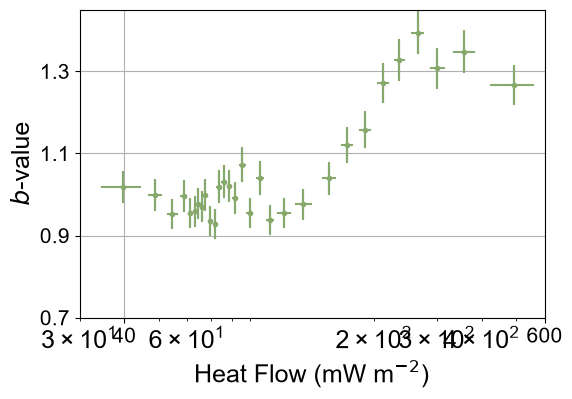

In [24]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 18 

width_inch = 237 / 25.4 
height_inch = 37 / 25.4 * 2
width_inch = height_inch

plt.figure(figsize=(6, 4))


plt.errorbar(HF_medio, Bvalue, yerr=Sigma, fmt='o', markerfacecolor='#87a96b', 
             markeredgecolor='#87a96b', markersize=3)


plt.grid(True)

plt.xlabel('Heat Flow (mW m$^{-2}$)')
plt.ylabel('$\\mathit{b}$-value')
plt.xscale('log')


plt.xticks([40, 600], labels=['40', '600'], fontsize=15)
plt.yticks(fontsize=15)
plt.ylim([0.7, 1.45])
plt.xlim([30, 600])
plt.yticks(np.arange(0.7, 1.45, 0.2))



for i in range(Intervalli):
    if not np.isnan(Bvalue[i]):
        plt.plot([HF_medio[i], HF_medio[i]], [Bvalue[i] - Sigma[i], Bvalue[i] + Sigma[i]], '#87a96b')
        plt.plot([HF_medio[i] - HF_std[i], HF_medio[i] + HF_std[i]], [Bvalue[i], Bvalue[i]], '#87a96b')

plt.show()

## Figure 3a

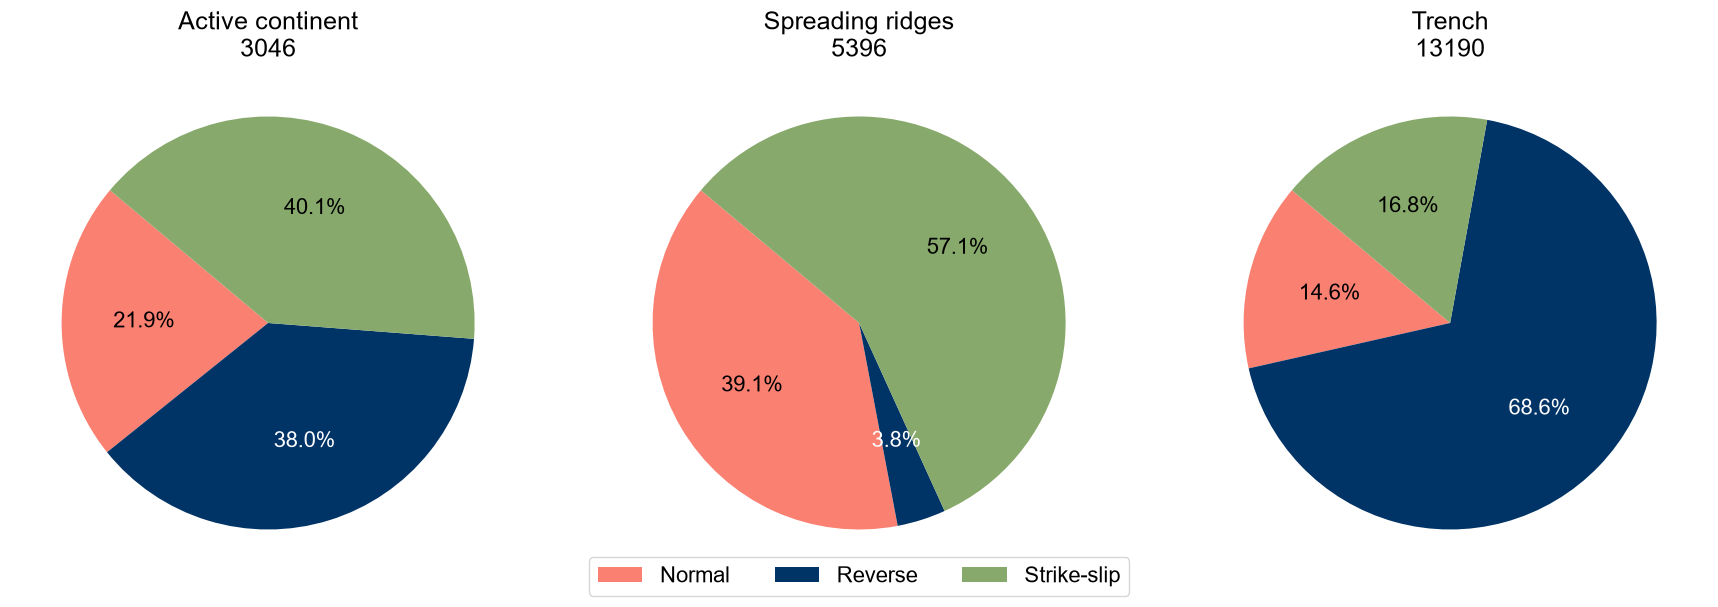

In [26]:
Dati = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])
Dati = Dati[Dati.Mag >= Dati.Mc]


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

classi = {
    1: "Active continent",
    2: "Spreading ridges",
    4: "Trench"
}

class_values = [1, [2, 3], 4]
colors = ['#fa8072', '#003366', '#87a96b']
labels = ['Normal', 'Reverse', 'Strike-slip']
def custom_autopct(pct, current_index):
    """Funzione per colorare le percentuali in modo personalizzato."""
    color = 'white' if colors[current_index] == '#003366' else 'black'
    return f'{pct:.1f}%', color

for ax, class_value, title in zip(axes, class_values, classi.keys()):
    if isinstance(class_value, list):
        Dati_filtered = Dati[Dati['Class'].isin(class_value)]
    else:
        Dati_filtered = Dati[Dati['Class'] == class_value]

    eventi_normali = Dati_filtered[(Dati_filtered['Rake1'] >= -135) & (Dati_filtered['Rake1'] <= -45)]
    eventi_inversi = Dati_filtered[(Dati_filtered['Rake1'] >= 45) & (Dati_filtered['Rake1'] <= 135)] 
    df23_ssd = Dati_filtered[(Dati_filtered['Rake1'] > -45) & (Dati_filtered['Rake1'] < 45)]
    df23_sss = Dati_filtered[(Dati_filtered['Rake1'] > 135) & (Dati_filtered['Rake1'] < -135)]
    eventi_trascorrenti = pd.concat([df23_ssd, df23_sss]).reset_index(drop=True)

    num_eventi = len(Dati_filtered)
    data = [len(eventi_normali), len(eventi_inversi), len(eventi_trascorrenti)]

    wedges, texts, autotexts = ax.pie(
        data, 
        autopct=lambda pct: custom_autopct(pct, data.index(max(data)))[0],
        colors=colors, 
        startangle=140, 
        textprops={'fontsize': 16}  
    )
    for i, autotext in enumerate(autotexts):
        if colors[i] == '#003366':  
            autotext.set_color('white')

    ax.set_title(f'{classi[title]}\n{num_eventi}', fontsize=18)

fig.legend(labels, loc='lower center', ncol=3, fontsize=16)
plt.tight_layout()
plt.show()

## b-values figure 3b,c,d

In [27]:
import numpy as np
import pandas as pd

def bvalue(Dati, mag, Mc):
    num_eventi = len(Dati)
    if num_eventi > 1:
        mean_magnitude_diff = np.mean(Dati[mag] - Dati[Mc])
        b_value = (num_eventi - 1) / num_eventi * 1 / (np.log(10) * mean_magnitude_diff)
        sigma = b_value / np.sqrt(num_eventi)
    else:
        b_value = np.nan
        sigma = np.nan
    
    return b_value, sigma


In [28]:
Dati = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])
Dati = Dati2[Dati.Mag >= Dati.Mc]
Dati = Dati[(Dati['Class'] == 1)] # change the number according to the tectonic area (1: active continent, 2 and 3:spreading ridges, 4: trench)

# uncomment for kinematics
Dati = Dati[(Dati['Rake1'] >= -135) & (Dati['Rake1'] <= -45)] # normal
#Dati = Dati[(Dati['Rake1'] >= 45) & (Dati['Rake1'] <= 135)] # reverse
# Dati_ssd = Dati[(Dati['Rake1'] > -45) & (Dati['Rake1'] < 45)] ##ss
# Dati_sss = Dati[(Dati['Rake1'] > 135) & (Dati['Rake1'] < -135)]# ss
# Dati = pd.concat([Dati_ssd, Dati_sss]).reset_index(drop=True) #ss

bvalue(Dati, 'Mag', 'Mc')

(np.float64(1.1329928881886002), np.float64(0.05226106489143824))

## Figure 3b,c,d

C:\Users\sydne\AppData\Local\Temp\ipykernel_38772\288108728.py:74: RuntimeWarning: divide by zero encountered in log10
  axs.plot(BinVec[:-1], np.log10(D2_1 / D2_1[0]), '.', markersize=7, color=colors[0], label=labels[0])
C:\Users\sydne\AppData\Local\Temp\ipykernel_38772\288108728.py:75: RuntimeWarning: divide by zero encountered in log10
  axs.plot(BinVec[:-1], np.log10(D2_2 / D2_2[0]), '.', markersize=7, color=colors[1], label=labels[1])
C:\Users\sydne\AppData\Local\Temp\ipykernel_38772\288108728.py:76: RuntimeWarning: divide by zero encountered in log10
  axs.plot(BinVec[:-1], np.log10(D2_3 / D2_3[0]), '.', markersize=7, color=colors[2], label=labels[2])


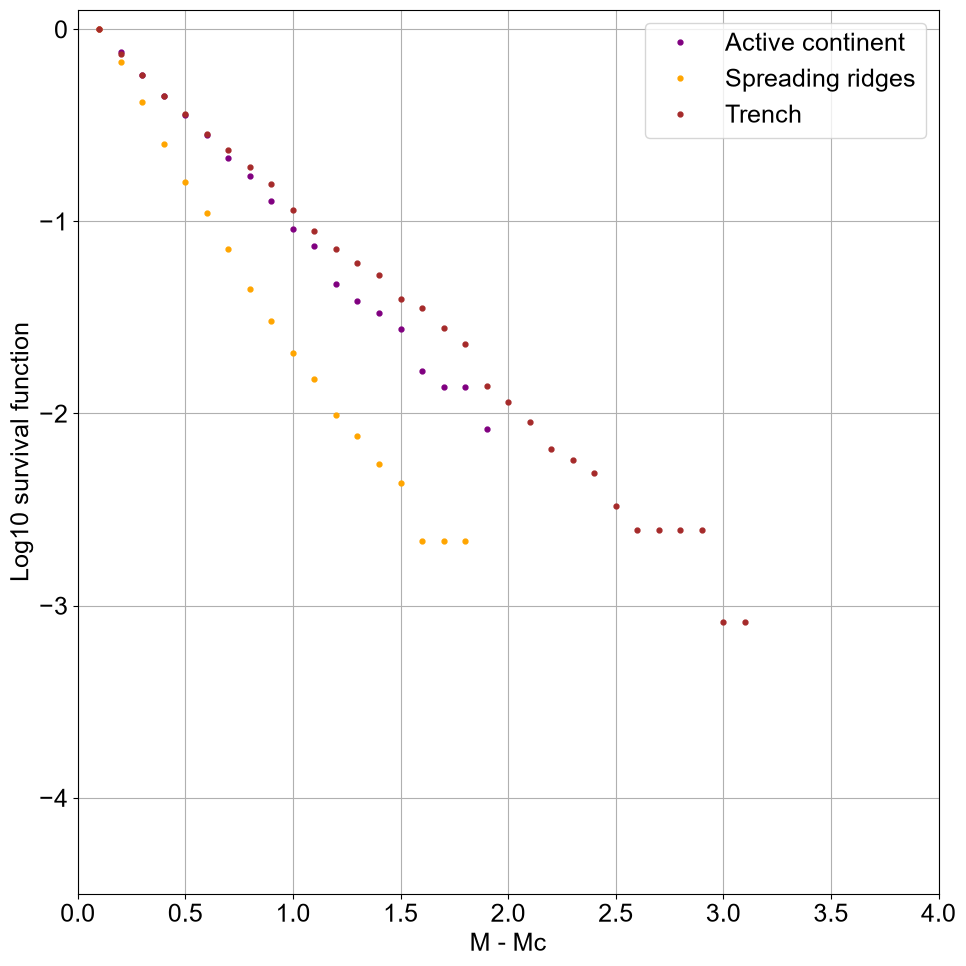

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dati = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])
#Dati = Dati[Dati.Mag >= Dati.Mc]

# Imposta il font Arial
plt.rcParams['font.family'] = 'Arial'

i
def Magnitude_Distribution(Catalog, MagnitudeColumn, Mc, BinVector):
    
    magnitudes = Catalog.iloc[:, MagnitudeColumn] - Catalog.iloc[:, Mc]
    
    
    D1, _ = np.histogram(magnitudes, bins=BinVector)
    
    
    D2one = np.cumsum(D1[::-1])  
    D2 = D2one[::-1] 
    
    return D1, D2


BinVec = np.arange(0.10, 9.1, 0.1)


def process_catalog_set(set_name):
    
    Cat1 = set_name[0]
    Cat2 = set_name[1]
    Cat3 = set_name[2]

    D1_1, D2_1 = Magnitude_Distribution(Cat1, 5, 17, BinVec)
    D1_2, D2_2 = Magnitude_Distribution(Cat2, 5, 17, BinVec)
    D1_3, D2_3 = Magnitude_Distribution(Cat3, 5, 17, BinVec)
    
    return D2_1, D2_2, D2_3

# 1 stands for active continent, 23 for ridges, 4 for trench; n stands for the normal kinematics. Change values to change kinematics (45-135 reverse; remaining strike slip)
df1_n_I = Dati[(Dati['Class'] == 1)] # change the number according to the tectonic area (1: active continent, 2 and 3:spreading ridges, 4: trench)
df1_n_I = df1_n_I[(df1_n_I['Rake1'] >= -135) & (df1_n_I['Rake1'] <= -45)] # normal

df23_n_I = Dati[(Dati['Class'] == 2) | (Dati['Class'] == 3)] # change the number according to the tectonic area (1: active continent, 2 and 3:spreading ridges, 4: trench)
df23_n_I = df23_n_I[(df23_n_I['Rake1'] >= -135) & (df23_n_I['Rake1'] <= -45)] # normal

df4_n_I = Dati[(Dati['Class'] == 4)] # change the number according to the tectonic area (1: active continent, 2 and 3:spreading ridges, 4: trench)
df4_n_I = df4_n_I[(df4_n_I['Rake1'] >= -135) & (df4_n_I['Rake1'] <= -45)] # normal



# Nomi dei set di cataloghi (ora sono liste di DataFrame)
catalog_sets = [
    [df1_n_I, df23_n_I, df4_n_I],  # Primo set
    [df1_n_I, df23_n_I, df4_n_I],  # Secondo set (puoi sostituirli con altri DataFrame)
    [df1_n_I, df23_n_I, df4_n_I]   # Terzo set (puoi sostituirli con altri DataFrame)
]

height_inch = 10  # circa 2.91 pollici
width_inch = height_inch   # larghezza per 3 plot

# Creazione della figura con dimensioni specificate
fig, axs = plt.subplots(1, 1, figsize=(width_inch, height_inch))  # Solo 1 plot

colors = ['#800080', '#ffa500', '#a52a2a']
labels = ['Active continent', 'Spreading ridges', 'Trench']

# Itera solo sul primo set di cataloghi
set_name = catalog_sets[0]
D2_1, D2_2, D2_3 = process_catalog_set(set_name)

axs.plot(BinVec[:-1], np.log10(D2_1 / D2_1[0]), '.', markersize=7, color=colors[0], label=labels[0])
axs.plot(BinVec[:-1], np.log10(D2_2 / D2_2[0]), '.', markersize=7, color=colors[1], label=labels[1])
axs.plot(BinVec[:-1], np.log10(D2_3 / D2_3[0]), '.', markersize=7, color=colors[2], label=labels[2])

axs.set_ylim([-4.5, 0.1])
axs.set_xlim([0, 4])
axs.set_xlabel('M - Mc')
axs.set_ylabel('Log10 survival function')
axs.legend()
axs.grid(True)

# Impostazioni generali del layout
plt.tight_layout()
plt.show()


## Figure ED5

P-value Active continent vs Ridge: 0
P-value Ridge vs Trench: 0.0
P-value Active continent vs Trench: 6.784986374967317e-35


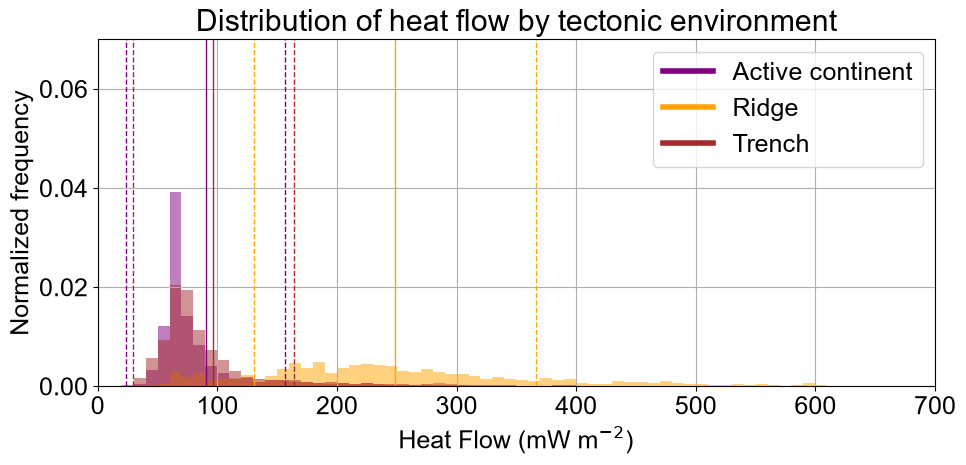

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ranksums
from matplotlib.lines import Line2D
import decimal

# Carica il catalogo
Cat = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])

# Colonna di heat flow e colonna della zona tettonica
HF_Col = 18  # In Python, gli indici partono da 0
TZ_Col = 16

# Seleziona gli eventi secondo la zona tettonica
Cat_Sel_1 = Cat[Cat.iloc[:, TZ_Col] == 1]  # Active continent
Cat_Sel_2 = Cat[(Cat.iloc[:, TZ_Col] == 2) | (Cat.iloc[:, TZ_Col] == 3)]  # Ridge
Cat_Sel_3 = Cat[Cat.iloc[:, TZ_Col] == 4]  # Trench

# Calcola media e deviazione standard dell'heat flow in ciascuna zona tettonica
M_S_1 = [np.mean(Cat_Sel_1.iloc[:, HF_Col]), np.std(Cat_Sel_1.iloc[:, HF_Col])]
M_S_2 = [np.mean(Cat_Sel_2.iloc[:, HF_Col]), np.std(Cat_Sel_2.iloc[:, HF_Col])]
M_S_3 = [np.mean(Cat_Sel_3.iloc[:, HF_Col]), np.std(Cat_Sel_3.iloc[:, HF_Col])]

# Esegui il test statistico per il confronto delle distribuzioni
Pvalue_12 = ranksums(Cat_Sel_1.iloc[:, HF_Col], Cat_Sel_2.iloc[:, HF_Col]).pvalue
Pvalue_12 = decimal.Decimal(Pvalue_12)
Pvalue_23 = ranksums(Cat_Sel_2.iloc[:, HF_Col], Cat_Sel_3.iloc[:, HF_Col]).pvalue
Pvalue_13 = ranksums(Cat_Sel_1.iloc[:, HF_Col], Cat_Sel_3.iloc[:, HF_Col]).pvalue

print(f"P-value Active continent vs Ridge: {Pvalue_12}")
print(f"P-value Ridge vs Trench: {Pvalue_23}")
print(f"P-value Active continent vs Trench: {Pvalue_13}")

# Plot degli istogrammi normalizzati
plt.figure(figsize=(10, 5))
plt.rcParams['font.family'] = 'Arial'

plt.hist(Cat_Sel_1.iloc[:, HF_Col], bins=np.arange(0, 700, 10), alpha=0.5, label='Active continent', density=True, color='#800080')
plt.hist(Cat_Sel_2.iloc[:, HF_Col], bins=np.arange(0, 700, 10), alpha=0.5, label='Ridge', density=True, color='#ffa500')
plt.hist(Cat_Sel_3.iloc[:, HF_Col], bins=np.arange(0, 700, 10), alpha=0.5, label='Trench', density=True, color='#a52a2a')

plt.xlim([0, 700])
plt.ylim([0, 0.07])
plt.xlabel('Heat Flow (mW m$^{-2}$)')
plt.ylabel('Normalized frequency')
plt.title('Distribution of heat flow by tectonic environment')

# Creazione di oggetti per la legenda
hist_legend_elements = [
    Line2D([0], [0], color='#800080', lw=4, label='Active continent'),
    Line2D([0], [0], color='#ffa500', lw=4, label='Ridge'),
    Line2D([0], [0], color='#a52a2a', lw=4, label='Trench')
]

plt.legend(handles=hist_legend_elements, loc='upper right')

# Aggiungi le linee verticali per la media e deviazione standard
plt.axvline(M_S_1[0], color='#800080', linestyle='-', linewidth=1)
plt.axvline(M_S_1[0] + M_S_1[1], color='#800080', linestyle='--', linewidth=1)
plt.axvline(M_S_1[0] - M_S_1[1], color='#800080', linestyle='--', linewidth=1)

plt.axvline(M_S_2[0], color='#ffa500', linestyle='-', linewidth=1)
plt.axvline(M_S_2[0] + M_S_2[1], color='#ffa500', linestyle='--', linewidth=1)
plt.axvline(M_S_2[0] - M_S_2[1], color='#ffa500', linestyle='--', linewidth=1)

plt.axvline(M_S_3[0], color='#a52a2a', linestyle='-', linewidth=1)
plt.axvline(M_S_3[0] + M_S_3[1], color='#a52a2a', linestyle='--', linewidth=1)
plt.axvline(M_S_3[0] - M_S_3[1], color='#a52a2a', linestyle='--', linewidth=1)

plt.grid(True)
plt.tight_layout()
plt.show()


## Figure ED6

Statistiche KS: 0.08249976300542572
P-value del test KS: 8.623172260421126e-29


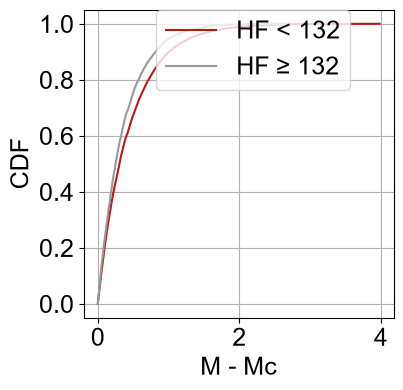

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp


Dati = pd.read_csv("..\\data\\Catalog_Complete_1980_2023_Depth50_withHF.txt", sep='\\s+', skiprows=1, 
                 names=['Lon','Lat','Year','Month','Day','Mag','Depth','Hour','Minute','Second','Strike1','Dip1','Rake1','Strike2','Dip2','Rake2','Class','Mc','HF'])
# uncomment remove spreading ridges
# Dati = Dati[(Dati['Class'] == 0) | (Dati['Class'] == 1) | (Dati['Class'] == 4)]


Dati['dM'] = Dati.Mag-Dati.Mc


ColonnaHF = 18
ColonnaMag = 5
ColonnaMag = 19


HF_basso = Dati[Dati.iloc[:, ColonnaHF] < 132]
HF_alto = Dati[Dati.iloc[:, ColonnaHF] >= 132]


mag_basso_values = HF_basso.iloc[:, ColonnaMag]
mag_alto_values = HF_alto.iloc[:, ColonnaMag]


stat, p_value = ks_2samp(mag_basso_values, mag_alto_values)
print(f"Statistiche KS: {stat}")
print(f"P-value del test KS: {p_value}")


mag_basso_cdf = np.sort(mag_basso_values)
mag_alto_cdf = np.sort(mag_alto_values)
cdf_basso = np.arange(1, len(mag_basso_cdf) + 1) / len(mag_basso_cdf)
cdf_alto = np.arange(1, len(mag_alto_cdf) + 1) / len(mag_alto_cdf)
plt.figure(figsize=(4, 4))
plt.plot(mag_basso_cdf, cdf_basso, label='HF < 132', color='#B31B1B')
plt.plot(mag_alto_cdf, cdf_alto, label='HF ≥ 132', color='#999999')
plt.xlabel('M - Mc')
plt.ylabel('CDF')



plt.legend(loc='lower right', bbox_to_anchor=(0.9, 0.7))  # Legenda più in alto

plt.grid(True)
plt.show()
